In [1]:
import pandas as pd
import torch
import json
import re
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel

d:\SVNIT\Semester - 6\Deep Learning\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("isgd_prompts.csv")
df.head()

,image_id,attractive,blurry_image,sharp_jawline,high_cheekbones,smiling,bald,receeding_hairline,long_hair,curly_hair,...,old,mouth_open,male,double_chin,veil,wrinkle,chubby,llama_prompt,mistral_prompt,gemma_prompt
0,00001.jpg,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,1,1,"The man's face was a warm and welcoming sight,...","The man's face was a warm and jovial sight, wi...","The man's face was a warm and jovial sight, wi..."
1,00002.jpg,1,0,0,1,1,0,0,1,0,...,0,1,0,0,0,0,0,"Her face is truly captivating, with high cheek...","The woman's face, framed by her thick, well-gr...","Her face was truly attractive, with thick eyeb..."
2,00003.jpg,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,"The man's face, framed by his well-groomed bla...","The man's face, framed by a well-groomed musta...","The man's face, framed by a well-groomed musta..."
3,00004.jpg,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,Her face was a stunning combination of sharp a...,Her face is a stunning combination of features...,Her face is a striking combination of delicate...
4,00005.jpg,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,1,"The man's face was rounded and chubby, with a ...",The man's face was a picture of relaxed jovial...,"The man's face was a rugged, weathered landsca..."


In [3]:
def clean_prompt(text):
    if pd.isna(text):
        return ""

    text = str(text).strip()

    # Keep only first sentence
    text = text.split(".")[0] + "."

    # Remove unwanted characters
    text = re.sub(r'[^a-zA-Z0-9 ,.]', '', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text)

    return text

In [4]:
for col in ["llama_prompt", "mistral_prompt", "gemma_prompt"]:
    df[col] = df[col].apply(clean_prompt)

df.head()

,image_id,attractive,blurry_image,sharp_jawline,high_cheekbones,smiling,bald,receeding_hairline,long_hair,curly_hair,...,old,mouth_open,male,double_chin,veil,wrinkle,chubby,llama_prompt,mistral_prompt,gemma_prompt
0,00001.jpg,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,1,1,"The mans face was a warm and welcoming sight, ...","The mans face was a warm and jovial sight, wit...","The mans face was a warm and jovial sight, wit..."
1,00002.jpg,1,0,0,1,1,0,0,1,0,...,0,1,0,0,0,0,0,"Her face is truly captivating, with high cheek...","The womans face, framed by her thick, wellgroo...","Her face was truly attractive, with thick eyeb..."
2,00003.jpg,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,"The mans face, framed by his wellgroomed black...","The mans face, framed by a wellgroomed mustach...","The mans face, framed by a wellgroomed mustach..."
3,00004.jpg,1,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,Her face was a stunning combination of sharp a...,Her face is a stunning combination of features...,Her face is a striking combination of delicate...
4,00005.jpg,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,1,1,"The mans face was rounded and chubby, with a t...",The mans face was a picture of relaxed joviali...,"The mans face was a rugged, weathered landscap..."


In [5]:
for i in range(5):
    print("IMAGE:", df.iloc[i]["image_id"])
    print("LLAMA:", df.iloc[i]["llama_prompt"])
    print("MISTRAL:", df.iloc[i]["mistral_prompt"])
    print("GEMMA:", df.iloc[i]["gemma_prompt"])
    print("-"*80)

IMAGE: 00001.jpg
LLAMA: The mans face was a warm and welcoming sight, with his high cheekbones accentuated by a bright, cheerful smile that spread across his chubby features, which were framed by a wellgroomed beard and mustache, and topped with a hat that cast a subtle shadow over the gentle wrinkles that etched his skin.
MISTRAL: The mans face was a warm and jovial sight, with a gentle smile spreading across his chubby cheeks, which were accentuated by high cheekbones, and framed by a wellgroomed beard and mustache, all of which was topped off by a hat, while a latticework of wrinkles etched into his skin added a sense of character and age.
GEMMA: The mans face was a warm and jovial sight, with his high cheekbones accentuated by a bright, beaming smile that creased his skin into a latticework of wrinkles, all framed by a wellgroomed beard and mustache, and topped off with a hat that added a touch of rugged charm to his rounded, chubby features.
---------------------------------------

In [6]:
df["final_prompt"] = df["llama_prompt"]

In [7]:
clip_data = []

for _, row in df.iterrows():
    clip_data.append({
        "image": f"ISGD/Images/{row['image_id']}",  # change path if needed
        "text": row["final_prompt"]
    })

with open("clip_dataset.json", "w") as f:
    json.dump(clip_data, f, indent=2)

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 48016.25it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
class CLIPDataset(Dataset):
    def __init__(self, data, processor):
        self.data = data
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = Image.open(item["image"]).convert("RGB")
        text = item["text"]

        return {"image": image, "text": text}

In [10]:
with open("clip_dataset.json") as f:
    data = json.load(f)

dataset = CLIPDataset(data, processor)

def collate_clip_batch(batch):
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]

    return processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_clip_batch)

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6)

model.train()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [12]:
for epoch in range(3):
    total_loss = 0

    for batch in tqdm(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch, return_loss=True)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(loader)}")

100%|██████████| 13/13 [00:02<00:00,  5.58it/s]


Epoch 1 Loss: 1.3828996740854704


100%|██████████| 13/13 [00:01<00:00,  6.60it/s]


Epoch 2 Loss: 0.6813071347199954


100%|██████████| 13/13 [00:01<00:00,  6.52it/s]

Epoch 3 Loss: 0.30654062995185644


In [13]:
model.save_pretrained("clip_finetuned")
processor.save_pretrained("clip_finetuned")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.05it/s]


['clip_finetuned\\processor_config.json']

In [17]:
model.eval()

query = "A man with beard and glasses"

text_inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    text_outputs = model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs.get("attention_mask")
    )
    text_emb = model.text_projection(text_outputs.pooler_output)

image_embeddings = []

for item in data:
    image = Image.open(item["image"]).convert("RGB")
    image_inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        vision_outputs = model.vision_model(pixel_values=image_inputs["pixel_values"])
        img_emb = model.visual_projection(vision_outputs.pooler_output)

    image_embeddings.append(img_emb.squeeze(0))

image_embeddings = torch.stack(image_embeddings)
text_emb = torch.nn.functional.normalize(text_emb, dim=-1)
image_embeddings = torch.nn.functional.normalize(image_embeddings, dim=-1)

# cosine similarity
similarity = image_embeddings @ text_emb.squeeze(0).unsqueeze(-1)
similarity = similarity.squeeze(-1)

top_k = similarity.topk(5)

print("Top matching images:")
for idx in top_k.indices:
    print(data[idx]["image"])

Top matching images:
ISGD/Images/00046.jpg
ISGD/Images/00075.jpg
ISGD/Images/00054.jpg
ISGD/Images/00100.jpg
ISGD/Images/00069.jpg


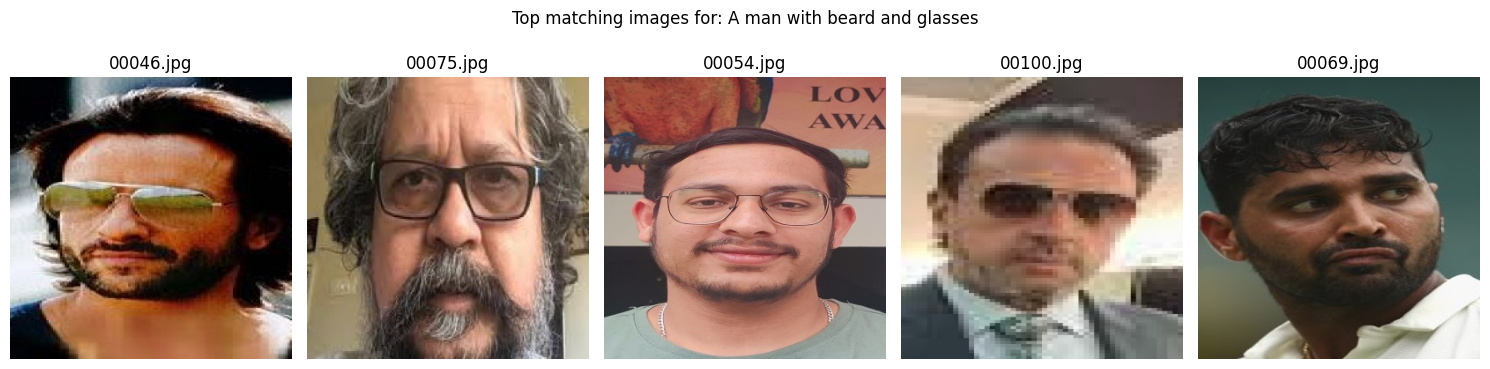

In [19]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(top_k.indices), figsize=(15, 4))

if len(top_k.indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, top_k.indices):
    image_path = data[int(idx)]["image"]
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(os.path.basename(image_path))
    ax.axis("off")

plt.suptitle(f"Top matching images for: {query}")
plt.tight_layout()
plt.show()